# Skenario 2: CNN Gambar — DenseNet-121 (S2)

**Input:** Citra X-ray dada (224×224 piksel, 3 channel RGB)  
**Model:** DenseNet-121 pretrained ImageNet (transfer learning)  
**Output:** Klasifikasi biner — Normal (0) vs Abnormal (1)  
**Tujuan:** Baseline performa menggunakan gambar X-ray saja, tanpa metadata tabular

Notebook ini menggunakan `ImageCNN` dari `src/models/architectures.py` dan `create_dataloaders()` dari `src/data/dataset.py`.

In [1]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, roc_curve, accuracy_score
)

from configs.config import cfg
from src.models.architectures import ImageCNN
from src.data.dataset import create_dataloaders

torch.manual_seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = cfg.paths.figures_dir
CKPT_DIR = cfg.paths.checkpoint_dir
TABLES_DIR = cfg.paths.project_root / "results" / "tables"
for d in [SAVE_DIR, CKPT_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"AMP     : {cfg.train.use_amp}")
print(f"Grad Accum Steps: {cfg.train.gradient_accumulation_steps} "
      f"(effective batch = {cfg.train.batch_size * cfg.train.gradient_accumulation_steps})")

Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM    : 6.4 GB
AMP     : True
Grad Accum Steps: 2 (effective batch = 32)


## 1. Load Dataset (Patient-Level Split)

In [2]:
# create_dataloaders() menangani: image index, metadata, patient-level split, transforms, scaler
train_loader, val_loader, test_loader, scaler, pos_weights = create_dataloaders(
    batch_size=cfg.train.batch_size
)

# pos_weight untuk binary — ambil rata-rata (untuk binary classification gunakan index 0)
# Hitung manual dari distribusi binary label di train split
print("\nDataloader siap.")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Hitung pos_weight binary dari train set
y_train_all = []
for batch in train_loader:
    y_train_all.append(batch["label_binary"].numpy())
y_train_all = np.concatenate(y_train_all)
pos_ratio = y_train_all.mean()
pw_binary = torch.tensor([(1 - pos_ratio) / pos_ratio], dtype=torch.float32).to(DEVICE)
print(f"\nPos ratio (train binary) : {pos_ratio:.3f}")
print(f"pos_weight               : {pw_binary.item():.3f}")

[Data] Indexed 112120 images across 12 directories
[Data] Loaded metadata: 112120 samples, 30805 patients
[Data] Split — Train: 77994 | Val: 8530 | Test: 25596

Dataloader siap.
Train batches : 4874
Val batches   : 267
Test batches  : 800

Pos ratio (train binary) : 0.417
pos_weight               : 1.400


## 2. Model, Optimizer, Scheduler

In [3]:
# S2: image-only, binary output
model = ImageCNN(num_classes=1).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pw_binary)
scaler_amp = GradScaler('cuda', enabled=cfg.train.use_amp)

# Differential learning rate: backbone lebih kecil dari head
# Branch sudah pre-trained ImageNet — jangan terlalu agresif
optimizer = torch.optim.AdamW([
    {"params": model.branch.parameters(),    "lr": cfg.train.lr_backbone},
    {"params": model.classifier.parameters(), "lr": cfg.train.lr_fusion},
], weight_decay=cfg.train.weight_decay)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=cfg.train.scheduler_patience,
    factor=cfg.train.scheduler_factor, verbose=True
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f"Model          : DenseNet-121 ImageCNN (S2 Binary)")
print(f"Total params   : {total_params:,}")
print(f"Trainable      : {trainable_params:,}")
print(f"Frozen (75%)   : {frozen_params:,}")
print(f"LR backbone    : {cfg.train.lr_backbone}")
print(f"LR head        : {cfg.train.lr_fusion}")

[ImageBranch] CheXNet weights loaded — all keys matched perfectly
Model          : DenseNet-121 ImageCNN (S2 Binary)
Total params   : 7,480,193
Trainable      : 2,582,241
Frozen (75%)   : 4,897,952
LR backbone    : 0.0001
LR head        : 0.0005


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 3. Training Loop

In [4]:
ACCUM_STEPS = cfg.train.gradient_accumulation_steps


def train_epoch(model, loader, criterion, optimizer, scaler_amp, device, accum_steps):
    model.train()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label_binary"].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images).squeeze(1)
            loss   = criterion(logits, labels) / accum_steps

        scaler_amp.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * accum_steps * len(labels)
        n += len(labels)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return total_loss / n, roc_auc_score(all_labels, all_probs)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label_binary"].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images).squeeze(1)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * len(labels)
        n += len(labels)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return total_loss / n, roc_auc_score(all_labels, all_probs), all_probs, all_labels


# ── Main training loop ──
CKPT_PATH = CKPT_DIR / "model_s2_cnn_image.pt"
history   = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_val_auc     = 0.0
patience_counter = 0
t0 = time.time()

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train AUC':>10} {'Val Loss':>10} {'Val AUC':>9} {'LR (bb)':>10} {'Time':>7}")
print("-" * 72)

for epoch in range(1, cfg.train.num_epochs + 1):
    ep_start = time.time()

    train_loss, train_auc = train_epoch(
        model, train_loader, criterion, optimizer, scaler_amp, DEVICE, ACCUM_STEPS
    )
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    scheduler.step(val_auc)
    current_lr = optimizer.param_groups[0]["lr"]
    ep_time    = time.time() - ep_start

    flag = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CKPT_PATH)
        patience_counter = 0
        flag = " ✓"
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_auc:>10.4f} "
          f"{val_loss:>10.4f} {val_auc:>9.4f} {current_lr:>10.2e} "
          f"{ep_time:>6.1f}s{flag}")

    if patience_counter >= cfg.train.early_stop_patience:
        print(f"\nEarly stopping di epoch {epoch} (patience={cfg.train.early_stop_patience})")
        break

total_time = time.time() - t0
print(f"\nTraining selesai dalam {total_time/60:.1f} menit")
print(f"Best Val AUC : {best_val_auc:.4f}")
print(f"Model tersimpan: {CKPT_PATH}")

Epoch   Train Loss  Train AUC   Val Loss   Val AUC    LR (bb)    Time
------------------------------------------------------------------------
    1       0.6825     0.7621     0.6604    0.7885   1.00e-04  891.4s ✓
    2       0.6750     0.7679     0.6562    0.7896   1.00e-04  791.2s ✓
    3       0.6735     0.7696     0.6778    0.7870   1.00e-04  724.7s
    4       0.6727     0.7700     0.6780    0.7897   1.00e-04  774.2s ✓
    5       0.6696     0.7732     0.6607    0.7889   1.00e-04  776.8s
    6       0.6707     0.7721     0.6765    0.7859   1.00e-04  742.7s
    7       0.6691     0.7737     0.6751    0.7882   1.00e-04  766.2s
    8       0.6693     0.7736     0.6591    0.7881   5.00e-05  768.2s
    9       0.6630     0.7782     0.6767    0.7887   5.00e-05  747.3s
   10       0.6612     0.7798     0.6717    0.7860   5.00e-05  758.3s
   11       0.6607     0.7801     0.6611    0.7862   5.00e-05  754.7s

Early stopping di epoch 11 (patience=7)

Training selesai dalam 141.6 menit
Best

## 4. Training Curves

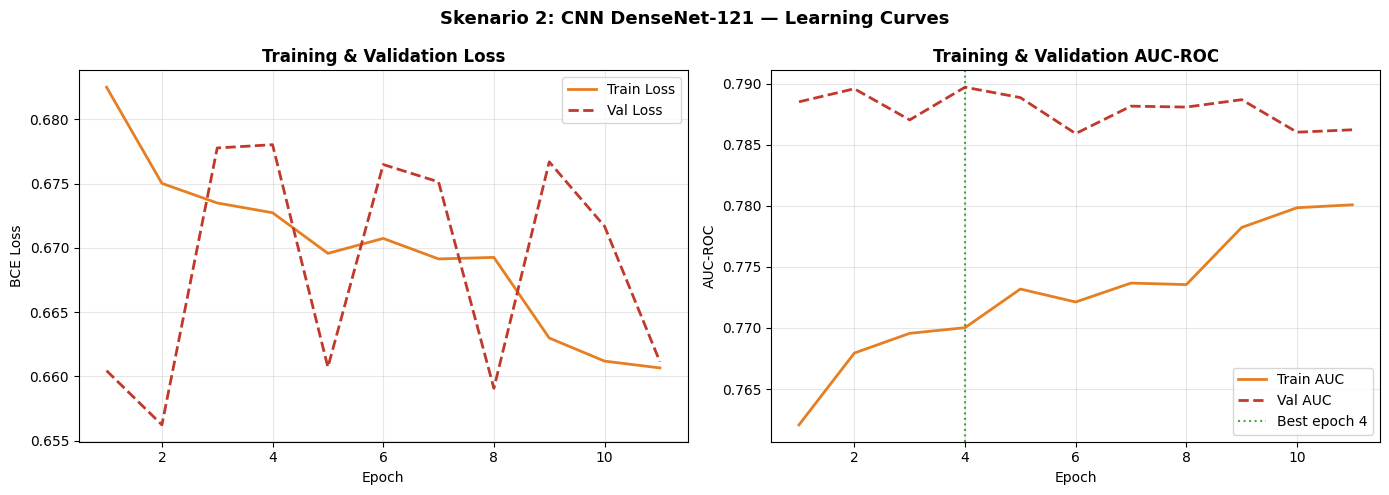

Disimpan → results/figures/s2_training_curves.png


In [5]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
best_ep    = np.argmax(history["val_auc"]) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss", color="#e67e22", linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Loss",   color="#c0392b", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training & Validation Loss", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["train_auc"], label="Train AUC", color="#e67e22", linewidth=2)
axes[1].plot(epochs_ran, history["val_auc"],   label="Val AUC",   color="#c0392b", linewidth=2, linestyle="--")
axes[1].axvline(best_ep, color="green", linestyle=":", alpha=0.7, label=f"Best epoch {best_ep}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("Training & Validation AUC-ROC", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Skenario 2: CNN DenseNet-121 — Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "s2_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s2_training_curves.png")

## 5. Evaluasi pada Test Set

In [6]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
_, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion, DEVICE)

test_preds = (test_probs >= 0.5).astype(int)

acc      = accuracy_score(test_labels, test_preds)
f1       = f1_score(test_labels, test_preds, average="binary")
f1_macro = f1_score(test_labels, test_preds, average="macro")
auc      = roc_auc_score(test_labels, test_probs)

print("=" * 55)
print("HASIL EVALUASI SKENARIO 2: CNN DenseNet-121")
print("=" * 55)
print(f"Accuracy       : {acc:.4f}")
print(f"F1-Score (bin) : {f1:.4f}")
print(f"F1-Score (mac) : {f1_macro:.4f}")
print(f"AUC-ROC        : {auc:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=["Normal", "Abnormal"]))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24980\431774902.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVIC

HASIL EVALUASI SKENARIO 2: CNN DenseNet-121
Accuracy       : 0.7318
F1-Score (bin) : 0.8022
F1-Score (mac) : 0.6930
AUC-ROC        : 0.7455

              precision    recall  f1-score   support

      Normal       0.73      0.49      0.58      9861
    Abnormal       0.73      0.88      0.80     15735

    accuracy                           0.73     25596
   macro avg       0.73      0.69      0.69     25596
weighted avg       0.73      0.73      0.72     25596



## 6. Confusion Matrix & ROC Curve

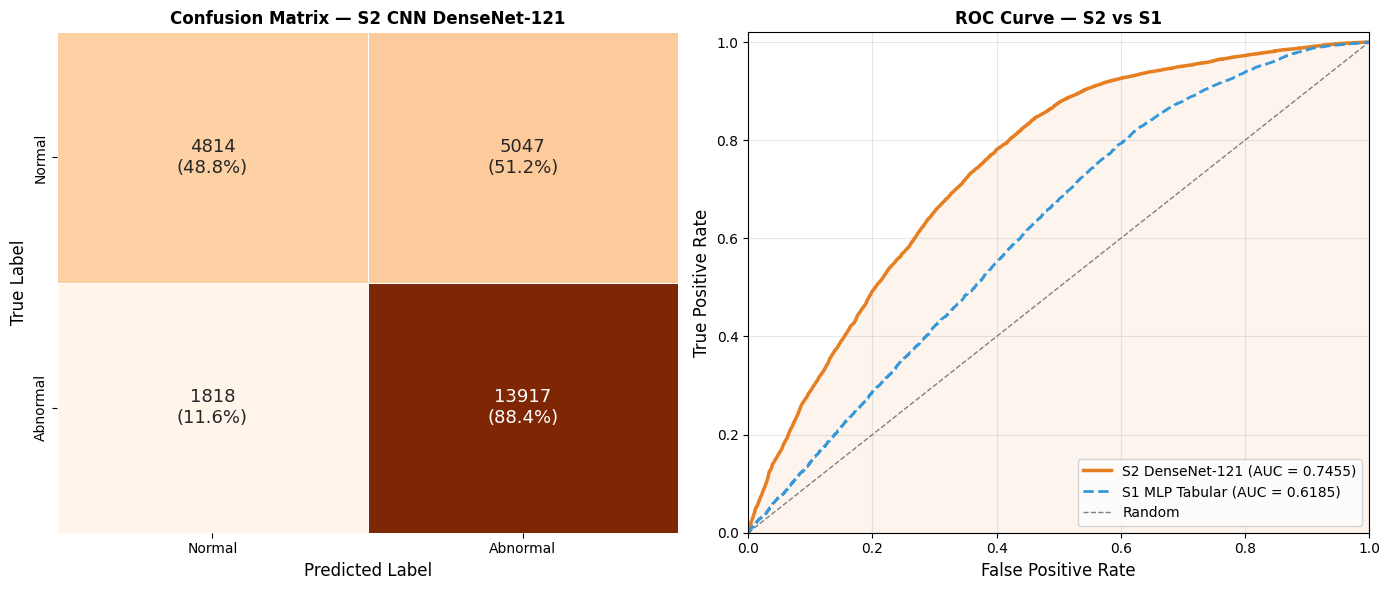

Disimpan → results/figures/s2_confusion_roc.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Confusion Matrix ──
cm     = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])

sns.heatmap(cm, annot=annot, fmt="", cmap="Oranges", ax=axes[0],
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"],
            linewidths=0.5, cbar=False, annot_kws={"size": 13})
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)
axes[0].set_title("Confusion Matrix — S2 CNN DenseNet-121", fontweight="bold")

# ── ROC Curve (S2 vs S1 jika ada) ──
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color="#e67e22", linewidth=2.5, label=f"S2 DenseNet-121 (AUC = {auc:.4f})")

# Load S1 untuk perbandingan (jika ada)
s1_path = TABLES_DIR / "predictions_s1.csv"
if s1_path.exists():
    df_s1 = pd.read_csv(s1_path)
    fpr_s1, tpr_s1, _ = roc_curve(df_s1["true_label"], df_s1["prob_s1"])
    auc_s1 = roc_auc_score(df_s1["true_label"], df_s1["prob_s1"])
    axes[1].plot(fpr_s1, tpr_s1, color="#3498db", linewidth=2, linestyle="--",
                 label=f"S1 MLP Tabular (AUC = {auc_s1:.4f})")

axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random")
axes[1].fill_between(fpr, tpr, alpha=0.08, color="#e67e22")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve — S2 vs S1", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(SAVE_DIR / "s2_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s2_confusion_roc.png")

## 7. Simpan Hasil

In [8]:
results_s2 = {
    "Skenario"    : "S2",
    "Model"       : "DenseNet-121",
    "Input"       : "Gambar X-ray (224×224)",
    "Accuracy"    : round(acc, 4),
    "F1 (Binary)" : round(f1, 4),
    "F1 (Macro)"  : round(f1_macro, 4),
    "AUC-ROC"     : round(auc, 4),
    "Best Epoch"  : best_ep,
    "Best Val AUC": round(best_val_auc, 4),
}

pd.DataFrame([results_s2]).to_csv(TABLES_DIR / "results_s2.csv", index=False)

pd.DataFrame({
    "true_label": test_labels.astype(int),
    "prob_s2"   : test_probs,
    "pred_s2"   : test_preds,
}).to_csv(TABLES_DIR / "predictions_s2.csv", index=False)

# Gabungkan dengan S1 jika ada
results_all = []
for f in ["results_s1.csv", "results_s2.csv"]:
    p = TABLES_DIR / f
    if p.exists():
        results_all.append(pd.read_csv(p))

if results_all:
    df_all = pd.concat(results_all, ignore_index=True)
    df_all.to_csv(TABLES_DIR / "results_summary.csv", index=False)
    print("Tabel Perbandingan S1 vs S2:")
    print(df_all[["Skenario", "Model", "Accuracy", "F1 (Binary)", "F1 (Macro)", "AUC-ROC"]].to_string(index=False))

print(f"\nModel checkpoint: {CKPT_PATH}")

Tabel Perbandingan S1 vs S2:
Skenario        Model  Accuracy  F1 (Binary)  F1 (Macro)  AUC-ROC
      S1  MLP Tabular    0.6559       0.7659      0.5586   0.6185
      S2 DenseNet-121    0.7318       0.8022      0.6930   0.7455

Model checkpoint: D:\TA\nih-multimodal\results\checkpoints\model_s2_cnn_image.pt


## 8. Ringkasan Skenario 2

| Metrik | Nilai |
|--------|-------|
| Accuracy | — |
| F1-Score (Binary) | — |
| F1-Score (Macro) | — |
| AUC-ROC | — |

> **Interpretasi:** DenseNet-121 dilatih dengan transfer learning ImageNet, freeze 75% layer awal, dan fine-tune 25% layer akhir + head. Performa dibandingkan dengan S1 (MLP Tabular) untuk mengukur kontribusi modalitas gambar. Kedua baseline ini menjadi acuan untuk menilai peningkatan yang diberikan oleh model multimodal di Skenario 3.

**Artefak yang dihasilkan:**
- `results/checkpoints/model_s2_cnn_image.pt` — bobot model terbaik
- `results/figures/s2_training_curves.png` — kurva training
- `results/figures/s2_confusion_roc.png` — confusion matrix + ROC curve (S2 vs S1)
- `results/tables/results_s2.csv` — tabel metrik evaluasi
- `results/tables/predictions_s2.csv` — probabilitas prediksi
- `results/tables/results_summary.csv` — perbandingan S1 vs S2